# 🔬 Chapter 2: Scientific Foundations of QRANDOPT
This chapter delves into the mathematical and physical principles underpinning the QRANDOPT dashboard.


## 1. Bias of a Bitstream
Given a binary random variable $X\in\{0,1\}$ with $P(X=1)=p$, the **bias** is defined as:

$$\mathrm{bias} = |p - 0.5|$$

It measures deviation from an ideal fair coin ($p=0.5$).

In [1]:
import numpy as np

# Example: generate 10,000 bits with p=0.6
bits = np.random.choice([0,1], size=10000, p=[0.4,0.6])
p_est = bits.mean()
bias = abs(p_est - 0.5)
print(f"Estimated p: {p_est:.4f}, Bias: {bias:.4f}")

Estimated p: 0.5889, Bias: 0.0889


## 2. Shannon Entropy
The Shannon entropy of a Bernoulli($p$) distribution is:

$$H(X) = -p \log_2 p - (1-p) \log_2(1-p)$$

It quantifies the average information per bit.


In [2]:
import numpy as np

def shannon_entropy(bits):
    p = bits.mean()
    q = 1 - p
    return -(p*np.log2(p+1e-9) + q*np.log2(q+1e-9))

ent = shannon_entropy(bits)
print(f"Shannon Entropy: {ent:.4f} bits")

Shannon Entropy: 0.9771 bits


## 3. Noise Impact on Bias
We can model a bit-flip noise channel with probability $\epsilon$: each bit is flipped independently with probability $\epsilon$.


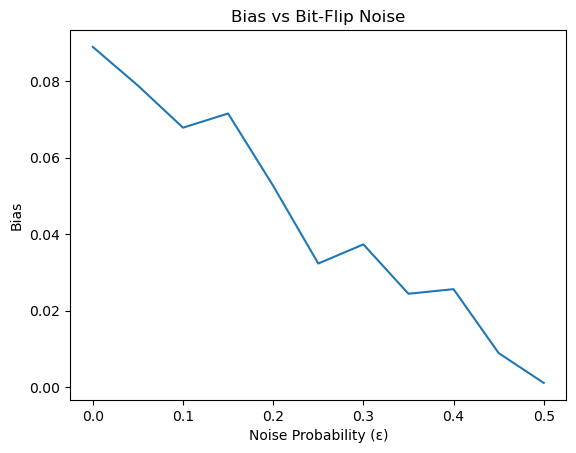

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def apply_noise(bits, eps):
    flips = np.random.rand(len(bits)) < eps
    return np.bitwise_xor(bits, flips)

# Sweep noise levels and compute bias
epsilons = np.linspace(0, 0.5, 11)
biases = []
for eps in epsilons:
    noisy = apply_noise(bits, eps)
    biases.append(abs(noisy.mean() - 0.5))

# Plotting
plt.figure()
plt.plot(epsilons, biases)
plt.xlabel('Noise Probability (ε)')
plt.ylabel('Bias')
plt.title('Bias vs Bit-Flip Noise')
plt.show()

## 4. Q-Learning Update Rule
The Q-learning update for state $s$, action $a$, next state $s'$ is:

$$Q(s,a) \leftarrow Q(s,a) + \alpha \bigl(r + \gamma \max_{a'} Q(s',a') - Q(s,a)\bigr)$$

Where:
- $\alpha$ is the learning rate
- $\gamma$ is the discount factor
- $r$ is the reward received.


## 5. Polynomial Hamiltonian for Dirac-3
Dirac-3 solves optimization of binary variables via a cost Hamiltonian:

$$H(\mathbf{x}) = \sum_i c_i x_i + \sum_{i<j} c_{ij} x_i x_j$$

Users upload coefficients $c_i, c_{ij}$ and Dirac-3 returns low-energy solutions.

